# Week 9 demo: difference-in-differences and government R&D funding

**Research question:** Does government R&D funding increase firm innovation?

This notebook uses a simulated panel of **300 firms observed annually from 2015 through 2023**, producing 2,700 firm-year observations. Some firms receive government R&D funding in 2020. Patent outcomes begin responding in 2021.

Because the data are simulated, the true treatment effect is known.

**Learning goals**

- Inspect raw outcome trends before fitting a model.
- Calculate a two-group, two-period DiD by hand.
- Estimate the equivalent interaction regression.
- Estimate a panel model with firm and year fixed effects.
- Use an event study to examine pretreatment trends and dynamic effects.
- Conduct a placebo test using only pretreatment data.

## Create the firm-year dataset

Funded firms have greater baseline innovation capacity, so their patent levels are higher even before funding. However, both groups follow the same expected trend before 2020.

The simulated treatment effect is dynamic:

- 2020: no immediate patent effect
- 2021: 0.8 additional patents
- 2022: 1.8 additional patents
- 2023: 2.8 additional patents

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from typing import Final

SEED: Final[int] = 610
FUNDING_YEAR: Final[int] = 2020
sns.set_theme(style="whitegrid", context="talk")

rng = np.random.default_rng(SEED)
n_firms = 300
years = np.arange(2015, 2024)

firm_ids = np.array([f"F{i:03d}" for i in range(1, n_firms + 1)])
industry = rng.choice(["Biotechnology", "Software", "Electronics", "Energy"],
                      size=n_firms, p=[0.22, 0.30, 0.28, 0.20])
innovation_capacity = rng.normal(0, 1, size=n_firms)
employees_pre = np.rint(np.exp(rng.normal(5.15 + 0.18 * innovation_capacity, 0.65, size=n_firms))).astype(int)

industry_funding_effect = {"Biotechnology": 0.45, "Software": -0.20,
                           "Electronics": 0.15, "Energy": 0.00}
funding_logit = -0.40 + 0.70 * innovation_capacity + 0.001 * employees_pre + np.array([industry_funding_effect[value] for value in industry])

funding_probability = 1 / (1 + np.exp(-funding_logit))
funded_group = rng.binomial(1, funding_probability)

industry_baseline = {"Biotechnology": 1.10, "Software": 0.20, "Electronics": 0.70, "Energy": 0.40}

year_effect = {year: 0.28 * (year - 2015) for year in years}
year_effect[2020] -= 0.45
year_effect[2022] += 0.25

true_effect_by_year = {2015: 0.0, 2016: 0.0, 2017: 0.0, 2018: 0.0,
                       2019: 0.0, 2020: 0.0, 2021: 0.8, 2022: 1.8, 2023: 2.8}

rows = []
for firm_number in range(n_firms):
    firm_baseline = 2.2 + 1.25 * innovation_capacity[firm_number] + 0.0025 * employees_pre[firm_number] + industry_baseline[industry[firm_number]]

    for year in years:
        treatment_effect = funded_group[firm_number] * true_effect_by_year[year]
        latent_patents = firm_baseline + year_effect[year] + treatment_effect + rng.normal(0, 1.2)

        patents = max(0, round(latent_patents))

        rows.append({"firm_id": firm_ids[firm_number], "year": year, "industry": industry[firm_number],
                     "employees_pre": employees_pre[firm_number], "funded_group": funded_group[firm_number],
                     "patents": patents, "true_effect": treatment_effect})

panel = pd.DataFrame(rows)
panel["group"] = panel["funded_group"].map({0: "Unfunded firms", 1: "Funded firms"})
panel["event_time"] = panel["year"] - FUNDING_YEAR
panel["post"] = (panel["year"] >= 2021).astype(int)
panel["funding_exposure"] = panel["funded_group"] * panel["post"]

print(f"Number of firms: {panel['firm_id'].nunique()}")
print(f"Number of firm-year observations: {len(panel):,}")
print(f"Funded firms: {funded_group.sum()}")
panel.head(12)

Number of firms: 300
Number of firm-year observations: 2,700
Funded firms: 139


,firm_id,year,industry,employees_pre,funded_group,patents,true_effect,group,event_time,post,funding_exposure
0,F001,2015,Software,498,0,5,0.0,Unfunded firms,-5,0,0
1,F001,2016,Software,498,0,5,0.0,Unfunded firms,-4,0,0
2,F001,2017,Software,498,0,5,0.0,Unfunded firms,-3,0,0
3,F001,2018,Software,498,0,4,0.0,Unfunded firms,-2,0,0
4,F001,2019,Software,498,0,5,0.0,Unfunded firms,-1,0,0
5,F001,2020,Software,498,0,4,0.0,Unfunded firms,0,0,0
6,F001,2021,Software,498,0,5,0.0,Unfunded firms,1,1,0
7,F001,2022,Software,498,0,7,0.0,Unfunded firms,2,1,0
8,F001,2023,Software,498,0,8,0.0,Unfunded firms,3,1,0
9,F002,2015,Software,163,0,6,0.0,Unfunded firms,-5,0,0


## Inspect the raw observed trends

Always begin with the actual outcome data. The groups may differ in levels while still showing similar pretreatment changes.

In [4]:
group_year_means = panel.groupby(["year", "group"], observed=True, as_index=False)["patents"].mean()
group_year_means.pivot(index="year", columns="group", values="patents").round(2)

group,Funded firms,Unfunded firms
year,,
2015,3.91,2.88
2016,4.13,3.27
2017,4.44,3.46
2018,4.55,3.71
2019,4.92,4.17
2020,4.76,3.86
2021,6.17,4.54
2022,7.81,5.04
2023,8.78,5.05


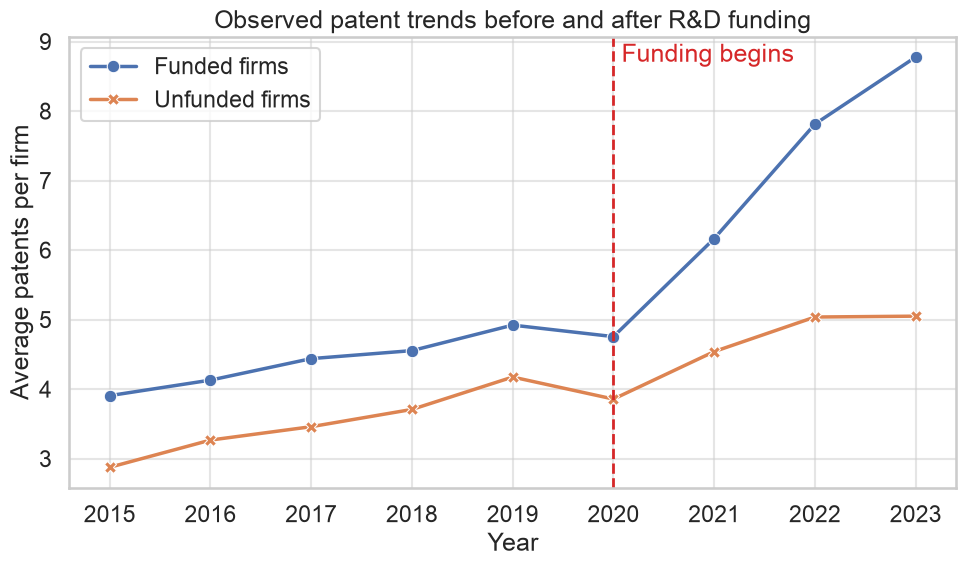

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
sns.lineplot(data=group_year_means, x="year", y="patents", hue="group", style="group",
             markers=True, dashes=False, linewidth=2.5, markersize=9, ax=ax)
ax.axvline(FUNDING_YEAR, color="tab:red", linestyle="--", linewidth=2)
ax.text(FUNDING_YEAR + 0.08, ax.get_ylim()[1] * 0.96, "Funding begins", color="tab:red")
ax.set(xlabel="Year", ylabel="Average patents per firm", title="Observed patent trends before and after R&D funding")
ax.legend(title="")


### Discussion

1. Do funded and unfunded firms have the same patent levels before funding?
2. Do their pretreatment changes appear reasonably parallel?
3. Why might the funding effect take time to appear in patent data?
4. Which external event might explain the temporary change in 2020?

## Calculate DiD by hand

For a simple two-period calculation, average 2015–2019 into the pretreatment period and 2021–2023 into the post-treatment period. The transition year 2020 is excluded because patents do not respond immediately.

In [19]:
did_sample = panel[panel["year"] != FUNDING_YEAR].copy()
did_sample["period"] = np.where(did_sample["year"] <= 2019, "Before funding","After funding",)

two_by_two = did_sample.groupby(["group", "period"], observed=True)["patents"].mean().unstack()
two_by_two = two_by_two[["Before funding", "After funding"]]
two_by_two["Change"] = two_by_two["After funding"] - two_by_two["Before funding"]
two_by_two.round(2)

period,Before funding,After funding,Change
group,,,
Funded firms,4.39,7.59,3.20
Unfunded firms,3.50,4.88,1.38


In [25]:
funded_change = two_by_two.loc["Funded firms", "Change"]
unfunded_change = two_by_two.loc["Unfunded firms", "Change"]
manual_did = funded_change - unfunded_change
true_post_effect = panel.loc[(panel["funded_group"] == 1) & (panel["post"] == 1), "true_effect"].mean()

print(f"Change among funded firms: {funded_change:.2f} patents")
print(f"Change among unfunded firms: {unfunded_change:.2f} patents")
print(f"Manual DiD estimate: {manual_did:.2f} patents")
print(f"True average post-funding effect: {true_post_effect:.2f} patents")

Change among funded firms: 3.20 patents
Change among unfunded firms: 1.38 patents
Manual DiD estimate: 1.82 patents
True average post-funding effect: 1.80 patents


## Estimate the two-group, two-period regression

The interaction coefficient should reproduce the manual DiD calculation:

$$
Y_{it}=\alpha+\beta Funded_i+\gamma Post_t+\delta(Funded_i\times Post_t)+\varepsilon_{it}
$$

In [26]:
two_period_model = smf.ols("patents ~ funded_group * post", data=did_sample).fit(cov_type="cluster", cov_kwds={"groups": did_sample["firm_id"]})

# Extract the DiD coefficient
interaction_name = "funded_group:post"
regression_did = two_period_model.params[interaction_name]
# Extract the confidence interval
regression_ci = two_period_model.conf_int().loc[interaction_name]

print(f"Manual DiD: {manual_did:.3f}")
print(f"Regression interaction: {regression_did:.3f}")
print(
    f"Clustered 95% CI: [{regression_ci.iloc[0]:.3f}, {regression_ci.iloc[1]:.3f}]"
)
two_period_model.summary().tables[1]

Manual DiD: 1.816
Regression interaction: 1.816
Clustered 95% CI: [1.597, 2.036]


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,3.4969,0.110,31.650,0.000,3.280,3.713
funded_group,0.8930,0.160,5.580,0.000,0.579,1.207
post,1.3789,0.074,18.735,0.000,1.235,1.523
funded_group:post,1.8163,0.112,16.198,0.000,1.597,2.036


## Estimate a panel model with fixed effects

Firm fixed effects account for stable differences between firms. Year fixed effects account for common shocks in each year.

$$
Y_{it}=\alpha_i+\lambda_t+\delta D_{it}+\varepsilon_{it}
$$

In [27]:
fixed_effects_model = smf.ols("patents ~ funding_exposure + C(firm_id) + C(year)",data=panel,).fit(cov_type="cluster",cov_kwds={"groups": panel["firm_id"]})

fe_estimate = fixed_effects_model.params["funding_exposure"]
fe_ci = fixed_effects_model.conf_int().loc["funding_exposure"]

results = pd.DataFrame({
    "estimate": [manual_did, regression_did, fe_estimate, true_post_effect],
}, index=["Manual DiD", "Interaction regression",
          "Firm and year fixed effects","True average post-funding effect"])
display(results.round(3))
print(f"Fixed-effects 95% CI: [{fe_ci.iloc[0]:.3f}, {fe_ci.iloc[1]:.3f}]")
# After controlling for firm fixed effects and year fixed effects, the estimated effect of funding on patent production is 1.815 patents.

,estimate
Manual DiD,1.816
Interaction regression,1.816
Firm and year fixed effects,1.815
True average post-funding effect,1.800


Fixed-effects 95% CI: [1.586, 2.045]


## Estimate an event study

- DiD: Did funding increase patent production on average?
- Event study: How did patent production change before and after firms received funding? Did the effect appear immediately, or did it take several years?

The year before funding, 2019, is the reference period. Pretreatment coefficients help diagnose whether the groups were already diverging. Post-treatment coefficients show how the funding effect develops.

In [28]:
# Define the event-study time periods
event_times = list(range(-5, 4))
reference_event_time = -1
event_columns = []
event_column_to_time = {}

for event_time in event_times:
    if event_time == reference_event_time:
        continue

    suffix = f"m{abs(event_time)}" if event_time < 0 else f"p{event_time}"
    column = f"event_{suffix}"
    panel[column] = ((panel["funded_group"] == 1) & (panel["event_time"] == event_time)).astype(int)
    event_columns.append(column)
    event_column_to_time[column] = event_time

event_formula = (
    "patents ~ "
    + " + ".join(event_columns)
    + " + C(firm_id) + C(year)"
)
event_model = smf.ols(event_formula, data=panel).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel["firm_id"]},
)

event_rows = []
for column in event_columns:
    interval = event_model.conf_int().loc[column]
    event_rows.append({
        "event_time": event_column_to_time[column],
        "estimate": event_model.params[column],
        "lower": interval.iloc[0],
        "upper": interval.iloc[1],
        "true_effect": true_effect_by_year[FUNDING_YEAR + event_column_to_time[column]],
    })

event_results = pd.DataFrame(event_rows)
reference_row = pd.DataFrame({
    "event_time": [reference_event_time],
    "estimate": [0.0],
    "lower": [0.0],
    "upper": [0.0],
    "true_effect": [0.0],
})
event_results = (
    pd.concat([event_results, reference_row], ignore_index=True)
    .sort_values("event_time")
    .reset_index(drop=True)
)
event_results.round(3)

,event_time,estimate,lower,upper,true_effect
0,-5,0.284,-0.143,0.711,0.0
1,-4,0.115,-0.287,0.518,0.0
2,-3,0.232,-0.190,0.654,0.0
3,-2,0.099,-0.334,0.532,0.0
4,-1,0.000,0.000,0.000,0.0
5,0,0.151,-0.258,0.560,0.0
6,1,0.878,0.460,1.296,0.8
7,2,2.029,1.612,2.445,1.8
8,3,2.980,2.523,3.438,2.8


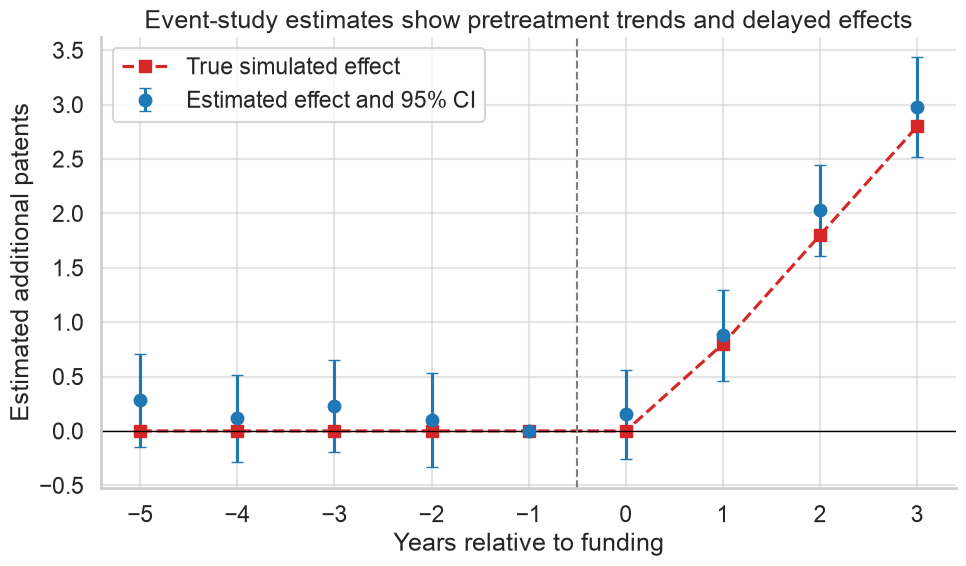

In [31]:
fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
ax.errorbar(
    event_results["event_time"],
    event_results["estimate"],
    yerr=[
        event_results["estimate"] - event_results["lower"],
        event_results["upper"] - event_results["estimate"],
    ],
    fmt="o",
    color="tab:blue",
    ecolor="tab:blue",
    capsize=4,
    label="Estimated effect and 95% CI",
)
ax.plot(
    event_results["event_time"],
    event_results["true_effect"],
    color="tab:red",
    marker="s",
    linestyle="--",
    label="True simulated effect",
)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(-0.5, color="tab:grey", linestyle="--", linewidth=1.5)
ax.set(
    xlabel="Years relative to funding",
    ylabel="Estimated additional patents",
    title="Event-study estimates show pretreatment trends and delayed effects",
)
ax.set_xticks(event_times)
ax.legend(title="")
sns.despine()


### Interpreting the event study

- Pretreatment estimates near zero are consistent with parallel trends.
- They do not prove what the untreated post-2020 trend would have been.
- The coefficient for 2020 should be near zero because innovation takes time.
- The post-treatment coefficients should grow as the simulated effect increases.

The raw trend plot and the event study answer different questions. The raw plot shows the actual outcome data. The event study presents regression-adjusted differences relative to the reference year. In an applied paper, it is often useful to report both.

## Pretreatment placebo test

Pretend that funding began in 2018 and use only data from 2015 through 2019. A large placebo effect would suggest that the groups were already diverging before the actual funding date.

In [32]:
placebo_sample = panel.loc[panel["year"] <= 2019].copy()
placebo_sample["placebo_post"] = (placebo_sample["year"] >= 2018).astype(int)
placebo_sample["placebo_treatment"] = (
    placebo_sample["funded_group"] * placebo_sample["placebo_post"]
)

placebo_model = smf.ols(
    "patents ~ placebo_treatment + C(firm_id) + C(year)",
    data=placebo_sample,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": placebo_sample["firm_id"]},
)

placebo_estimate = placebo_model.params["placebo_treatment"]
placebo_ci = placebo_model.conf_int().loc["placebo_treatment"]
placebo_pvalue = placebo_model.pvalues["placebo_treatment"]
print(f"Placebo estimate: {placebo_estimate:.3f} patents")
print(
    f"Clustered 95% CI: [{placebo_ci.iloc[0]:.3f}, {placebo_ci.iloc[1]:.3f}]"
)
print(f"P-value: {placebo_pvalue:.4f}")

Placebo estimate: -0.161 patents
Clustered 95% CI: [-0.440, 0.118]
P-value: 0.2576


## Interpretation and limitations

A suitable interpretation is:

> After accounting for stable differences between firms and common changes over time, government R&D funding was associated with an average increase of approximately 1.8 patents per funded firm during 2021–2023, assuming that funded and unfunded firms would otherwise have followed parallel trends.

**What the design addresses**

- Stable differences between firms
- Shocks shared by all firms in the same year
- Baseline differences in patent levels

**What the design does not automatically address**

- Different untreated trends between the groups
- Policies affecting only funded firms at the same time
- Anticipatory behavior before the funding date
- Spillovers from funded firms to comparison firms
- Changes in patent measurement or firm composition

### Final discussion

1. Why did we exclude 2020 from the simple two-period calculation?
2. Would patent applications or patent grants provide a better outcome?
3. What characteristics would help identify a more credible comparison group?
4. How might matching improve this DiD design?
5. What would change if firms received funding in different years?